# Decision Tree (ID3)

In [1]:
from mlscratch.tree import DecisionTreeID3
import pandas as pd
from sklearn.metrics import accuracy_score

### Play Tennis
We use the `DecisionTreeID3` class on the classic "play tennis" dataset, which records whether tennis was played given the weather. Every feature is categorical, which is what ID3 is built for.

To start we build the dataset as a pandas DataFrame. Unlike the other models in this library, `DecisionTreeID3` is fitted on the whole table, features and target together, rather than on separate `X` and `y`.

In [2]:
data = pd.DataFrame([
    {"Outlook": "Sun",      "Humidity": "High",   "Wind": "Weak",   "Play": "No"},
    {"Outlook": "Sun",      "Humidity": "High",   "Wind": "Strong", "Play": "No"},
    {"Outlook": "Overcast", "Humidity": "High",   "Wind": "Weak",   "Play": "Yes"},
    {"Outlook": "Rain",     "Humidity": "High",   "Wind": "Weak",   "Play": "Yes"},
    {"Outlook": "Rain",     "Humidity": "Normal", "Wind": "Weak",   "Play": "Yes"},
    {"Outlook": "Rain",     "Humidity": "Normal", "Wind": "Strong", "Play": "No"},
    {"Outlook": "Overcast", "Humidity": "Normal", "Wind": "Strong", "Play": "Yes"},
    {"Outlook": "Sun",      "Humidity": "Normal", "Wind": "Weak",   "Play": "Yes"},
    {"Outlook": "Sun",      "Humidity": "High",   "Wind": "Weak",   "Play": "No"},
    {"Outlook": "Rain",     "Humidity": "High",   "Wind": "Strong", "Play": "No"},
    {"Outlook": "Overcast", "Humidity": "High",   "Wind": "Strong", "Play": "Yes"},
    {"Outlook": "Sun",      "Humidity": "Normal", "Wind": "Strong", "Play": "Yes"},
])
data

,Outlook,Humidity,Wind,Play
0,Sun,High,Weak,No
1,Sun,High,Strong,No
2,Overcast,High,Weak,Yes
3,Rain,High,Weak,Yes
4,Rain,Normal,Weak,Yes
5,Rain,Normal,Strong,No
6,Overcast,Normal,Strong,Yes
7,Sun,Normal,Weak,Yes
8,Sun,High,Weak,No
9,Rain,High,Strong,No


We then create an instance of `DecisionTreeID3`, here called `model`. It takes two arguments: `features`, a dict mapping each feature to every value it can take, and `target`, the name of the column to predict. Listing every value means the tree gets a branch for each one, even a value that never reaches a particular node during training; that branch predicts the majority class at that node.

In [3]:
feature_domains = {
    "Outlook":  ["Sun", "Overcast", "Rain"],
    "Humidity": ["High", "Normal"],
    "Wind":     ["Weak", "Strong"],
}

model = DecisionTreeID3(feature_domains, target="Play")

All the methods implemented in this library follow the standard `fit` and `predict` workflow. Since this is purely an example notebook, the model is trained on the whole dataset and predicts on the same dataset.

In [4]:
model.fit(data)

`predict` classifies one row at a time, so we apply it to each row of the table.

In [5]:
y_pred = data.apply(model.predict, axis=1)
accuracy_score(data["Play"], y_pred)

1.0

`plot` draws the fitted tree. Blue boxes are the features it splits on, the labels on the edges are feature values, and green boxes are the predicted classes. At each node, ID3 splits on the feature with the highest information gain.

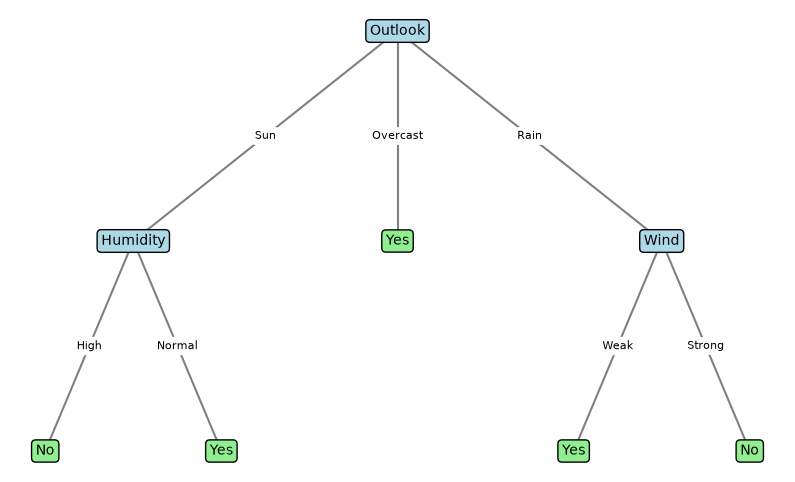

In [6]:
model.plot();

To classify a new day, pass its feature values as a dict. This combination doesn't appear in the training data.

In [7]:
model.predict({"Outlook": "Overcast", "Humidity": "Normal", "Wind": "Weak"})

'Yes'